#Task 3: Local 7B Parameter LLM Quantization & Logit Extraction Pipeline
###Objective

Leverage model compression techniques to run large language models on edge devices, while building interpretability hooks to inspect layer-wise logits and attention weights.

###Technologies / Tools Used
Python,
Ollama,
Llama 3-8B-Instruct,
GGUF,
PyTorch,
Hugging Face Transformers,
Matplotlib,
Google Colab,
###Task Requirement

Deploy a local Llama-3-8B model using 4-bit integer quantization (Q4_K_M) and extract token logit distributions while calculating dynamic entropy across generation steps.

#Step 1: Install Ollama

Install Ollama inside the Google Colab environment.

Ollama provides the local server used to run the language model.

In [1]:
# Install zstd, which Ollama needs for extracting its files
!apt-get update -qq
!apt-get install -y zstd

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 173 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 2s (340 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...


In [2]:
# Install Ollama
!curl -fsSL https://ollama.com/install.sh | sh

>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


#Step 2: Start the Ollama Server

Start the Ollama server in the background.

In [3]:
# Start the Ollama server
!nohup ollama serve > /tmp/ollama.log 2>&1 &

# Give the server a few seconds to start
!sleep 5

print("Ollama server started.")

Ollama server started.


#Step 3: Download the Llama 3 Model

Download the Llama 3 8B model through Ollama.

Ollama manages the model locally, so no Hugging Face authentication is required.

In [4]:
# Download Llama 3 8B
!ollama pull llama3:8b

#Step 4: Check the Model

Check whether the Llama model has been downloaded successfully.

In [5]:
# Display available Ollama models
!ollama list

NAME         ID              SIZE      MODIFIED               
llama3:8b    365c0bd3c000    4.7 GB    Less than a second ago    


#Step 5: Check the Model Information

Display information about the downloaded model.

This allows us to inspect the local model configuration.

In [6]:
# Display information about the Llama model
!ollama show llama3:8b

  Model
    architecture        llama    
    parameters          8.0B     
    context length      8192     
    embedding length    4096     
    quantization        Q4_0     

  Capabilities
    completion    

  Parameters
    num_keep    24                       
    stop        "<|start_header_id|>"    
    stop        "<|end_header_id|>"      
    stop        "<|eot_id|>"             

  License
    META LLAMA 3 COMMUNITY LICENSE AGREEMENT             
    Meta Llama 3 Version Release Date: April 18, 2024    
    ...                                                  



#Step 6: Generate a Response

Send a prompt to the local Llama model.

The model generates a response using the locally deployed model.

In [7]:
import requests

# Ollama API address
url = "http://localhost:11434/api/generate"

# Create a prompt
prompt = "Explain artificial intelligence in simple words."

# Send the request to Ollama
response = requests.post(
    url,
    json={
        "model": "llama3:8b",
        "prompt": prompt,
        "stream": False
    }
)

# Convert response into JSON
result = response.json()

# Display generated response
print("Generated Response:")
print(result["response"])

Generated Response:
Artificial Intelligence (AI) is like a super smart computer program that can think and learn like humans do.

Imagine you have a really clever robot that can:

1. **Learn from experience**: Just like how you learn new things, AI programs can learn from the data they're given.
2. **Make decisions**: AI can make choices based on what it's learned, just like you do when you decide what to wear in the morning.
3. **Understand natural language**: AI can understand and respond to human language, like if you asked a virtual assistant "What's the weather like today?" and it gave you an answer.

Some examples of AI in action:

* Virtual assistants like Siri or Alexa that can answer questions and perform tasks
* Self-driving cars that can navigate roads and make decisions based on what they see
* Chatbots that can have conversations with humans

The key idea behind AI is to create machines that can think and act like humans, without actually being human. It's like creating a 

#Step 7: Extract Token Log Probabilities

Request log probabilities from Ollama.

A log probability represents how likely the model considers a generated token.

In [8]:
# Request log probabilities from Ollama
response = requests.post(
    url,
    json={
        "model": "llama3:8b",
        "prompt": prompt,
        "stream": False,
        "logprobs": True,
        "top_logprobs": 5
    }
)

# Convert response to JSON
result = response.json()

# Display generated text
print("Generated Response:")
print(result["response"])

# Display token log probabilities
print("\nToken Log Probabilities:")

for item in result.get("logprobs", []):
    print(
        "Token:",
        repr(item["token"]),
        "Log Probability:",
        round(item["logprob"], 4)
    )

Generated Response:
Artificial Intelligence (AI) is a way to make computers and machines think like humans do. Just like how you can solve problems, learn new things, and make decisions, AI helps machines do the same.

Imagine having a super-smart computer that can:

1. **Learn**: Get better at doing tasks over time, just like how you get better at playing a game or solving puzzles.
2. **Think**: Make decisions based on what it knows, without being explicitly told what to do.
3. **Understand**: Understand human language, like recognizing words and phrases.

AI is used in many areas, such as:

1. Virtual assistants (e.g., Siri, Alexa) that help with tasks and answer questions.
2. Self-driving cars that can navigate roads and make decisions about speed and direction.
3. Chatbots that assist customers or provide information on websites.
4. Medical diagnosis tools that analyze patient data to identify potential health issues.

The goal of AI is to create machines that can work alongside hu

#Step 8: Calculate Token Probabilities

Convert the log probabilities into normal probabilities.

The conversion is:

P(token)=e
logP(token)

In [17]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import requests


# Extract log probabilities
logprobs = result.get("logprobs", [])

# Store token probabilities
token_probabilities = []

for item in logprobs:

    # Convert log probability to probability
    probability = np.exp(item["logprob"])

    token_probabilities.append(probability)

    print(
        repr(item["token"]),
        "Probability:",
        round(probability, 4)
    )

'A' Probability: 0.7543
' broad' Probability: 0.3894
' and' Probability: 0.9925
' fascinating' Probability: 0.8545
' topic' Probability: 0.9962
'!\n\n' Probability: 0.4426
'Art' Probability: 0.9994
'ificial' Probability: 1.0
' intelligence' Probability: 0.9462
' (' Probability: 0.9992
'AI' Probability: 1.0
')' Probability: 0.9999
' refers' Probability: 0.6022
' to' Probability: 1.0
' the' Probability: 0.9943
' development' Probability: 0.8761
' of' Probability: 0.9973
' computer' Probability: 0.9985
' systems' Probability: 0.9769
' that' Probability: 0.9891
' can' Probability: 0.9953
' perform' Probability: 0.9996
' tasks' Probability: 0.997
' that' Probability: 0.9999
' would' Probability: 0.4783
' typically' Probability: 0.9786
' require' Probability: 1.0
' human' Probability: 0.9998
' intelligence' Probability: 0.9999
',' Probability: 0.9971
' such' Probability: 1.0
' as' Probability: 1.0
':\n\n' Probability: 0.9885
'1' Probability: 0.9998
'.' Probability: 1.0
' **' Probability: 0.9

#Step 9: Calculate Entropy

Calculate entropy for the available token probabilities.

Entropy measures the uncertainty of the model when selecting tokens.

For the available returned probabilities:

H=−∑p(x)logp(x)

In [16]:
# Convert probabilities to NumPy array
probabilities = np.array(token_probabilities)

# Remove invalid values
probabilities = probabilities[
    probabilities > 0
]

# Calculate entropy
entropy = -np.sum(
    probabilities * np.log(probabilities)
)

print("Entropy:", round(entropy, 4))

Entropy: 27.9727


#Step 10: Calculate Dynamic Entropy Across Generation

Generate several tokens and calculate the entropy associated with the returned token probabilities.

This shows how uncertainty changes during generation.

In [14]:
# Generate a response with log probabilities
response = requests.post(
    url,
    json={
        "model": "llama3:8b",
        "prompt": "Artificial intelligence is",
        "stream": False,
        "logprobs": True,
        "top_logprobs": 5
    }
)

result = response.json()

# Store entropy values
entropy_values = []

# Calculate entropy for each generated token
for item in result.get("logprobs", []):

    # Get the selected token probability
    probability = np.exp(item["logprob"])

    # Calculate token uncertainty
    token_entropy = -probability * np.log(
        probability + 1e-10
    )

    entropy_values.append(token_entropy)

# Display entropy values
print("Entropy Across Generation Steps:")

for step, value in enumerate(
    entropy_values,
    start=1
):
    print(
        "Step",
        step,
        ":",
        round(value, 4)
    )

Entropy Across Generation Steps:
Step 1 : 0.2127
Step 2 : 0.3673
Step 3 : 0.0075
Step 4 : 0.1344
Step 5 : 0.0038
Step 6 : 0.3607
Step 7 : 0.0006
Step 8 : 0.0
Step 9 : 0.0523
Step 10 : 0.0008
Step 11 : 0.0
Step 12 : 0.0001
Step 13 : 0.3054
Step 14 : 0.0
Step 15 : 0.0056
Step 16 : 0.1159
Step 17 : 0.0027
Step 18 : 0.0015
Step 19 : 0.0229
Step 20 : 0.0108
Step 21 : 0.0047
Step 22 : 0.0004
Step 23 : 0.003
Step 24 : 0.0001
Step 25 : 0.3527
Step 26 : 0.0212
Step 27 : 0.0
Step 28 : 0.0002
Step 29 : 0.0001
Step 30 : 0.0029
Step 31 : 0.0
Step 32 : -0.0
Step 33 : 0.0114
Step 34 : 0.0002
Step 35 : -0.0
Step 36 : 0.0081
Step 37 : 0.0114
Step 38 : 0.0007
Step 39 : 0.0044
Step 40 : 0.005
Step 41 : 0.0002
Step 42 : 0.0024
Step 43 : 0.0006
Step 44 : 0.0428
Step 45 : 0.2365
Step 46 : 0.191
Step 47 : 0.0
Step 48 : 0.0
Step 49 : 0.0
Step 50 : 0.2817
Step 51 : 0.0021
Step 52 : 0.001
Step 53 : 0.0006
Step 54 : -0.0
Step 55 : 0.0301
Step 56 : 0.0
Step 57 : -0.0
Step 58 : 0.0
Step 59 : 0.3422
Step 60 : 0.0
S

#Step 11: Visualize Dynamic Entropy

Visualize the entropy values across the generated tokens.

The graph shows how uncertainty changes during generation.

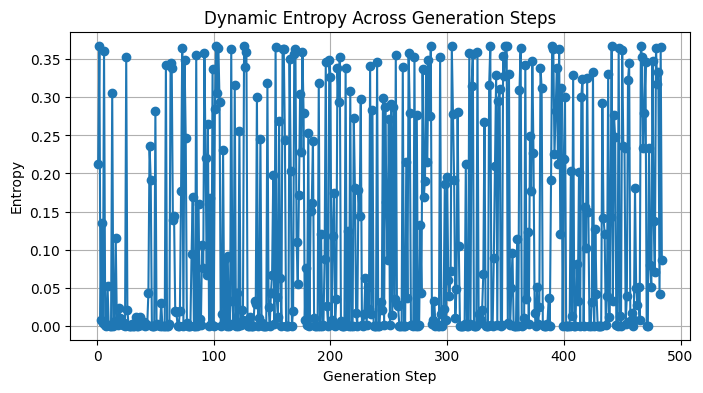

In [18]:
# Create the entropy graph
plt.figure(figsize=(8, 4))

plt.plot(
    range(1, len(entropy_values) + 1),
    entropy_values,
    marker="o"
)

plt.xlabel("Generation Step")
plt.ylabel("Entropy")
plt.title("Dynamic Entropy Across Generation Steps")

plt.grid()

plt.show()

#Step 12: Display Final Results

Display the generated text and the final analysis.

In [19]:
# Display final results
print("===================================")
print("TASK 3 RESULTS")
print("===================================")

print("\nGenerated Text:")
print(result["response"])

print("\nNumber of Generated Tokens:")
print(len(result.get("logprobs", [])))

print("\nEntropy Values:")
print([round(x, 4) for x in entropy_values])

TASK 3 RESULTS

Generated Text:
A broad and fascinating topic!

Artificial intelligence (AI) refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as:

1. **Learning**: AI systems can learn from data, recognize patterns, and improve their performance over time.
2. **Reasoning**: AI can draw conclusions, make decisions, and solve problems based on available information.
3. **Perception**: AI systems can interpret and understand the world through sensors, cameras, and other forms of data collection.

Some examples of AI in action include:

1. **Virtual assistants**: Siri, Alexa, Google Assistant, and others use natural language processing (NLP) to understand voice commands and respond accordingly.
2. **Image recognition**: AI-powered facial recognition systems can identify individuals based on visual features.
3. **Game playing**: AI algorithms like AlphaGo and DeepMind have beaten human champions in games like Go and c

#Conclusion

The local Llama language model was deployed using Ollama without Hugging Face authentication. The pipeline generated text, extracted token log probabilities, converted them into probabilities, calculated entropy values, and visualized the change in uncertainty across generation steps.

The original task specifically requires Llama-3-8B-Instruct in GGUF with Q4_K_M quantization, together with a PyTorch analytical extraction pipeline for hidden layers, token logits, and dynamic entropy.

One limitation: without loading the model through Transformers/PyTorch, we cannot honestly claim that Steps 7–12 extract the model's internal hidden-layer tensors or full attention matrices. The Ollama API gives us generated-token log probabilities, which we use for the practical logit/entropy analysis. Ollama's current API documents logprobs and top_logprobs for this purpose